In [3]:
from google.colab import files
uploaded = files.upload()   # pick BOTH csv files in the file picker that pops up

Saving archive (4).zip to archive (4).zip
Saving archive (3).zip to archive (3).zip


In [4]:
import os

print(os.listdir())

['.config', 'archive (3).zip', 'archive (4).zip', 'sample_data']


In [5]:
import zipfile

for zip_name in ['archive (4).zip', 'archive (3).zip']:
    with zipfile.ZipFile(zip_name, 'r') as z:
        print(f"\nContents of {zip_name}:")
        print(z.namelist())
        z.extractall()


Contents of archive (4).zip:
['NetflixOriginals.csv', 'archive (3).zip']

Contents of archive (3).zip:
['netflix_movies_and_tv_shows.csv']


In [6]:
import pandas as pd

catalog_df = pd.read_csv('netflix_movies_and_tv_shows.csv')
originals_df = pd.read_csv('NetflixOriginals.csv', encoding='latin-1')

print("Catalog shape:", catalog_df.shape)
print("Originals shape:", originals_df.shape)

Catalog shape: (5642, 15)
Originals shape: (584, 6)


In [7]:
catalog_df.head()

,title,type,titlereleased,rating,quality,actors,director,category,imdb,runtime,netflixid,date_released,description,4k,language
0,#blackAF,TV,2020,TV-MA,UltraHD,"Kenya Barris, Rashida Jones, Iman Benson, Genn...",NaN,NaN,6.6,NaN,81056700,2020-04-17,Kenya Barris and his family navigate relations...,1,english
1,#cats_the_mewvie,TV,2020,TV-14,SuperHD,NaN,Michael Margolis,NaN,5.2,89,81218137,2020-02-05,This pawesome documentary explores how our fel...,0,english
2,#realityhigh,TV,2017,TV-14,UltraHD,"Nesta Cooper, Kate Walsh, John Michael Higgins...",Fernando Lebrija,NaN,5.2,99,80125979,2017-09-08,When nerdy high schooler Dani finally attracts...,1,english
3,#Rucker50,TV,2016,TV-G,SuperHD,NaN,Robert McCullough Jr.,NaN,5.3,56,80147908,2016-12-01,This documentary celebrates the 50th anniversa...,0,english
4,#Selfie,TV,2014,TV-MA,SuperHD,"Flavia Hojda, Crina Semciuc, Olimpia Melinte, ...",Cristina Jacob,NaN,6.1,125,81092768,2019-06-01,"Two days before their final exams, three teen ...",0,other


In [8]:
originals_df.head()

,Title,Genre,Premiere,Runtime,IMDB Score,Language
0,Enter the Anime,Documentary,"August 5, 2019",58,2.5,English/Japanese
1,Dark Forces,Thriller,"August 21, 2020",81,2.6,Spanish
2,The App,Science fiction/Drama,"December 26, 2019",79,2.6,Italian
3,The Open House,Horror thriller,"January 19, 2018",94,3.2,English
4,Kaali Khuhi,Mystery,"October 30, 2020",90,3.4,Hindi


In [9]:
print("CATALOG COLUMNS:")
print(catalog_df.columns.tolist())
print(catalog_df.dtypes)
print("\nMissing values per column:")
print(catalog_df.isnull().sum())

CATALOG COLUMNS:
['title', 'type', 'titlereleased', 'rating', 'quality', 'actors', 'director', 'category', 'imdb', 'runtime', 'netflixid', 'date_released', 'description', '4k', 'language']
title            object
type             object
titlereleased    object
rating           object
quality          object
actors           object
director         object
category         object
imdb             object
runtime          object
netflixid         int64
date_released    object
description      object
4k                int64
language         object
dtype: object

Missing values per column:
title               0
type                0
titlereleased      46
rating              0
quality          1043
actors            443
director         2024
category         4494
imdb             1212
runtime          1917
netflixid           0
date_released       0
description         0
4k                  0
language            0
dtype: int64


In [10]:
print("ORIGINALS COLUMNS:")
print(originals_df.columns.tolist())
print(originals_df.dtypes)
print("\nMissing values per column:")
print(originals_df.isnull().sum())

ORIGINALS COLUMNS:
['Title', 'Genre', 'Premiere', 'Runtime', 'IMDB Score', 'Language']
Title          object
Genre          object
Premiere       object
Runtime         int64
IMDB Score    float64
Language       object
dtype: object

Missing values per column:
Title         0
Genre         0
Premiere      0
Runtime       0
IMDB Score    0
Language      0
dtype: int64


In [11]:
print("Unique non-null values in 'category':")
print(catalog_df['category'].dropna().unique()[:20])

print("\nSample of 'imdb' column values:")
print(catalog_df['imdb'].unique()[:30])

Unique non-null values in 'category':
['Documentary, Reality-TV' 'Comedy, History, Romance' 'Thrillers'
 'Reality-TV' 'Documentary' 'Romance, Teen, Comedy'
 'Historical, Documentary, True Crime' 'LGBTQ, Reality' 'Drama, War'
 'Animation, Adventure, Comedy, Family, Fantasy' 'Sci-fi, Japanese'
 'Animation, Comedy, Family' 'Drama, Romance' 'Animation'
 'Game-Show, Reality-TV' 'Documentary, Music' 'Comedy'
 'Animation, Action, Adventure, Family, Fantasy, Mystery'
 'Drama, Romance, Sci-Fi' 'Documentary, Crime']

Sample of 'imdb' column values:
['6.6' '5.2' '5.3' '6.1' '6.3' nan '6.5' '5.8' '5.6' '7.5' '7.3' '7.8'
 '8.2' '6.9' '5.4' '6.8' '8.8' '7.4' '6.4' '6.7' '5.7' '7.7' '3.9' '7.2'
 '7.6' '7.1' '5.9' '8.1' '8.4' '5.5']


In [12]:
numeric_check= pd.to_numeric(catalog_df['imdb'],errors='coerce')
problem_rows=  catalog_df[numeric_check.isna() & catalog_df['imdb'].notna()]
print("Number of problem values:",len(problem_rows))
print("\n The actual problem values:")
print(problem_rows['imdb'].unique())

Number of problem values: 23

 The actual problem values:
['N']


In [13]:
catalog_df['imdb'] = pd.to_numeric(catalog_df['imdb'], errors='coerce')

print("New dtype:", catalog_df['imdb'].dtype)
print("Missing values now:", catalog_df['imdb'].isnull().sum())

New dtype: float64
Missing values now: 1235


In [14]:
print(catalog_df['type'].value_counts())
print("\n")
print(catalog_df['rating'].value_counts())
print("\n")
print(catalog_df['date_released'].head(10))
print("\n")
print(catalog_df['runtime'].unique()[:20])

type
TV             4519
Movie          1116
standup           4
Documentary       3
Name: count, dtype: int64


rating
TV-MA       2397
TV-14       1435
TV-PG        540
R            324
TV-Y         250
TV-Y7        203
PG-13        187
TV-G         152
PG           120
G             23
TV-Y7-FV       6
NR             2
PG             1
NC-17          1
M              1
Name: count, dtype: int64


0    2020-04-17
1    2020-02-05
2    2017-09-08
3    2016-12-01
4    2019-06-01
5    2019-06-01
6    2020-08-12
7    2019-09-01
8    2019-03-20
9    2019-10-18
Name: date_released, dtype: object


[nan '89' '99' '56' '125' '118' '148' '87' '96' '75 min' '93' '108' '44'
 '29' '100' '36' '84' '124' '102' '51 mins']


In [15]:
catalog_df['type']= catalog_df['type'].replace({
    'standup':'Movie',
    'Documentary':'Movie',
    'TV':'TV Show'
})

catalog_df['rating']=catalog_df['rating'].str.strip()

catalog_df['date_released']=pd.to_datetime(catalog_df['date_released'],errors='coerce')

catalog_df['runtime']=catalog_df['runtime'].astype(str).str.replace(r'\s*mins?', '' ,regex=True)
catalog_df['runtime']=pd.to_numeric(catalog_df['runtime'] , errors='coerce')


print("Type count now:\n",catalog_df['type'].value_counts())
print("\n Rating count now:\n",catalog_df['rating'].value_counts())
print("\n Date dtype now:\n",catalog_df['date_released'].dtype)
print("\n Runtime dtype now:\n",catalog_df['runtime'].dtype)
print("\n Runtime missing Values:\n",catalog_df['runtime'].isnull().sum())

Type count now:
 type
TV Show    4519
Movie      1123
Name: count, dtype: int64

 Rating count now:
 rating
TV-MA       2397
TV-14       1435
TV-PG        540
R            324
TV-Y         250
TV-Y7        203
PG-13        187
TV-G         152
PG           121
G             23
TV-Y7-FV       6
NR             2
NC-17          1
M              1
Name: count, dtype: int64

 Date dtype now:
 datetime64[ns]

 Runtime dtype now:
 float64

 Runtime missing Values:
 1918


In [16]:
print(catalog_df['quality'].value_counts())

quality
SuperHD    3466
UltraHD     976
SD          148
HD            9
Name: count, dtype: int64


In [17]:
catalog_df['quality']=catalog_df['quality'].fillna('Not specified')
print(catalog_df['quality'].value_counts())

quality
SuperHD          3466
Not specified    1043
UltraHD           976
SD                148
HD                  9
Name: count, dtype: int64


In [18]:
print(catalog_df.isnull().sum())
print("\n Final Catalog Shape:",catalog_df.shape)

title               0
type                0
titlereleased      46
rating              0
quality             0
actors            443
director         2024
category         4494
imdb             1235
runtime          1918
netflixid           0
date_released       0
description         0
4k                  0
language            0
dtype: int64

 Final Catalog Shape: (5642, 15)


In [19]:
originals_df['Premiere'] = pd.to_datetime(originals_df['Premiere'], errors='coerce')
print(originals_df.dtypes)
print("\nMissing Premiere dates:", originals_df['Premiere'].isnull().sum())

Title                 object
Genre                 object
Premiere      datetime64[ns]
Runtime                int64
IMDB Score           float64
Language              object
dtype: object

Missing Premiere dates: 5


In [20]:
print(originals_df['Premiere'].head(10))
print(originals_df['Premiere'].dtype)


0   2019-08-05
1   2020-08-21
2   2019-12-26
3   2018-01-19
4   2020-10-30
5   2019-11-01
6   2020-12-04
7   2020-06-05
8   2018-03-23
9   2021-05-18
Name: Premiere, dtype: datetime64[ns]
datetime64[ns]


In [21]:
# Re-load Premiere fresh from the original column, ignoring any earlier broken attempts
originals_df = pd.read_csv('NetflixOriginals.csv', encoding='latin-1')
originals_df['Premiere'] = pd.to_datetime(originals_df['Premiere'], errors='coerce')

print(originals_df.dtypes)
print("\nMissing Premiere dates:", originals_df['Premiere'].isnull().sum())
print(originals_df[['Title','Premiere']].head())

Title                 object
Genre                 object
Premiere      datetime64[ns]
Runtime                int64
IMDB Score           float64
Language              object
dtype: object

Missing Premiere dates: 5
             Title   Premiere
0  Enter the Anime 2019-08-05
1      Dark Forces 2020-08-21
2          The App 2019-12-26
3   The Open House 2018-01-19
4      Kaali Khuhi 2020-10-30


In [22]:
catalog_df.to_csv('netflix_catalog_clean.csv',index=False)
originals_df.to_csv('netflix_originals_clean.csv',index=False)

from google.colab import files
files.download('netflix_catalog_clean.csv')
files.download('netflix_originals_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
import pandas as pd

catalog_df = pd.read_csv('netflix_movies_and_tv_shows.csv')

catalog_df['type'] = catalog_df['type'].replace({
    'standup': 'Movie',
    'Documentary': 'Movie',
    'TV': 'TV Show'
})
catalog_df['rating'] = catalog_df['rating'].str.strip()
catalog_df['date_released'] = pd.to_datetime(catalog_df['date_released'], errors='coerce')
catalog_df['runtime'] = catalog_df['runtime'].astype(str).str.replace(r'\s*mins?', '', regex=True)
catalog_df['runtime'] = pd.to_numeric(catalog_df['runtime'], errors='coerce')
catalog_df['imdb'] = pd.to_numeric(catalog_df['imdb'], errors='coerce')
catalog_df['quality'] = catalog_df['quality'].fillna('Not Specified')

print("Catalog shape:", catalog_df.shape)
print(catalog_df.dtypes)
print("\nMissing values:\n", catalog_df.isnull().sum())

Catalog shape: (5642, 15)
title                    object
type                     object
titlereleased            object
rating                   object
quality                  object
actors                   object
director                 object
category                 object
imdb                    float64
runtime                 float64
netflixid                 int64
date_released    datetime64[ns]
description              object
4k                        int64
language                 object
dtype: object

Missing values:
 title               0
type                0
titlereleased      46
rating              0
quality             0
actors            443
director         2024
category         4494
imdb             1235
runtime          1918
netflixid           0
date_released       0
description         0
4k                  0
language            0
dtype: int64


In [24]:
from google.colab import auth
auth.authenticate_user()
print("Authenticated successfully")

MessageError: Error: credential propagation was unsuccessful

In [25]:
import csv

catalog_df.to_csv('netflix_catalog_clean_v2.csv', index=False, quoting=csv.QUOTE_ALL)
originals_df.to_csv('netflix_originals_clean_v2.csv', index=False, quoting=csv.QUOTE_ALL)

from google.colab import files
files.download('netflix_catalog_clean_v2.csv')
files.download('netflix_originals_clean_v2.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Correlation: -0.041
P-value: 0.324


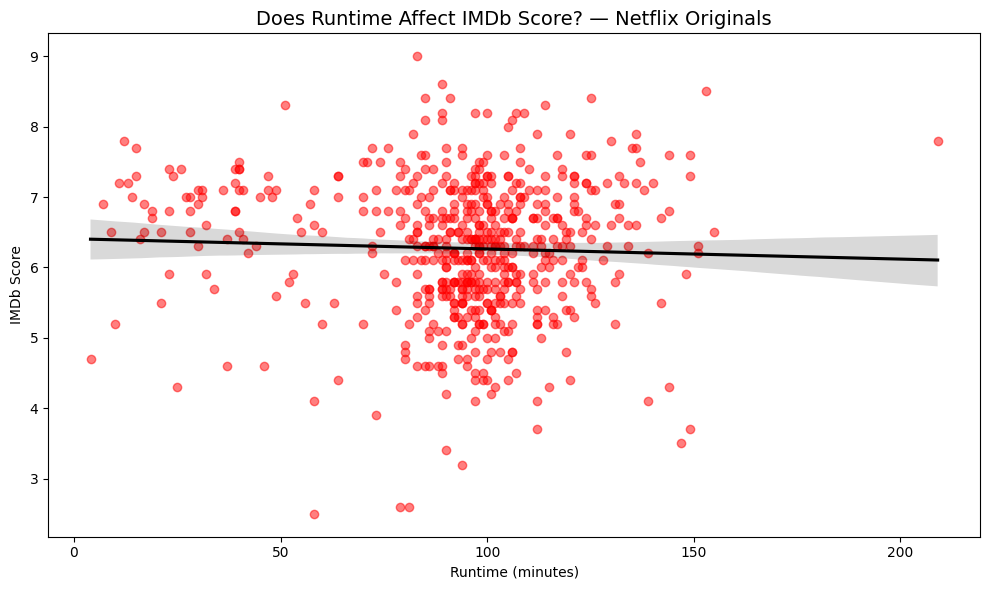

In [27]:


# Load clean data
originals_df = pd.read_csv('NetflixOriginals.csv', encoding='latin-1')

# Calculate correlation
correlation, pvalue = stats.pearsonr(
    originals_df['Runtime'],
    originals_df['IMDB Score']
)
print(f"Correlation: {correlation:.3f}")
print(f"P-value: {pvalue:.3f}")

# Scatter plot
plt.figure(figsize=(10, 6))
sns.regplot(
    data=originals_df,
    x='Runtime',
    y='IMDB Score',
    scatter_kws={'alpha':0.5, 'color':'red'},
    line_kws={'color':'black'}
)
plt.title('Does Runtime Affect IMDb Score? — Netflix Originals', fontsize=14)
plt.xlabel('Runtime (minutes)')
plt.ylabel('IMDb Score')
plt.tight_layout()
plt.savefig('runtime_vs_imdb.png', dpi=150)
plt.show()

In [28]:
from google.colab import files
files.download('runtime_vs_imdb.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>